## Desafio 1 da Trilha de Visão Computacional — Blur de Fundo

> **Resumo:** Implementamos um "blur de fundo" estilo chamada de vídeo: detectamos o(s) rosto(s)
> com **Haar Cascade**, borramos a imagem inteira com **desfoque Gaussiano** e recolocamos os
> rostos originais (nítidos) por cima. Resultado: pessoa em foco, fundo desfocado.

> 📝 **Ideia central:** é um truque clássico de composição — `fundo_borrado` + `recorte_nítido` na
> região de interesse. Sem segmentação pesada, só detecção de face + máscara retangular.

### Instalação e Importação da Biblioteca

In [1]:
!pip install opencv-python matplotlib

In [2]:
import cv2
import matplotlib.pyplot as plt

### Ler Imagens

O OpenCV lê em **BGR**; convertemos para **RGB** para visualizar corretamente com o matplotlib.

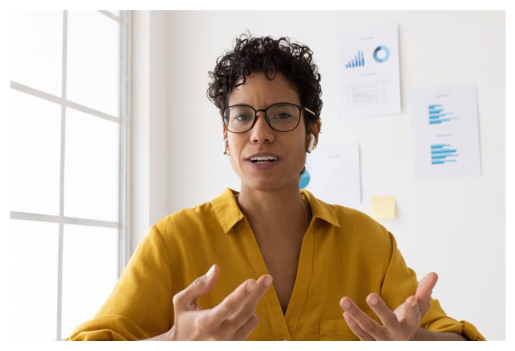

Shape da imagem: (534, 800, 3)


In [3]:
image_bgr = cv2.imread("desafio_1.jpeg")          # Leia a imagem do arquivo "desafio_1.jpeg"
image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)  # Converta de BGR para RGB para visualização
plt.imshow(image_rgb)
plt.axis("off")
plt.show()
print(f"Shape da imagem: {image_rgb.shape}")

### Transformar em Escala de Cinza

O detector Haar Cascade trabalha sobre a imagem em tons de cinza (só intensidade, sem cor).

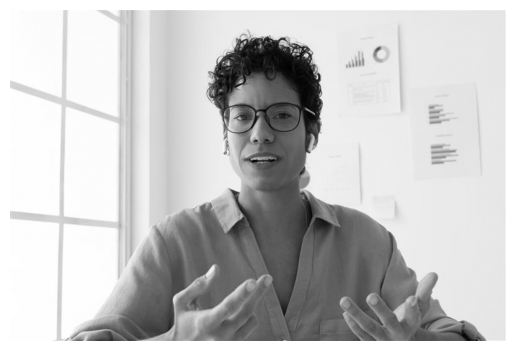

In [4]:
image_gray = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2GRAY)  # Converte imagem para tons de cinza
plt.imshow(image_gray, cmap="gray")
plt.axis("off")
plt.show()

### Detectar as Faces

Usamos o `haar cascade`, um método clássico de detecção de faces. Mais detalhes [aqui](https://docs.opencv.org/3.4/db/d28/tutorial_cascade_classifier.html).

`detectMultiScale(img, scaleFactor=1.3, minNeighbors=3)` retorna uma lista de caixas `(x, y, largura, altura)`.
Para cada rosto guardamos a caixa **com um padding** (folga), que usaremos depois para recolocar o recorte nítido.

Faces detectadas: 1


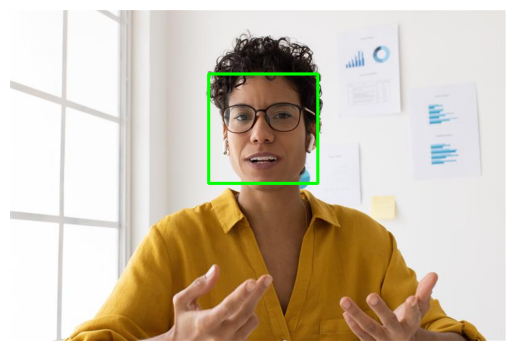

In [5]:
detec = cv2.CascadeClassifier("haarcascade_frontalface_default.xml")
faces = detec.detectMultiScale(image_gray, 1.3, 3)
print(f"Faces detectadas: {len(faces)}")

copy_image_rgb = image_rgb.copy()
padding = 20  # pixels de folga em cada direção ao redor do rosto

# Guardamos as coordenadas (já com padding e "clampadas" às bordas) de cada rosto.
face_boxes = []
for (x, y, larg, alt) in faces:  # Desenhar o retângulo de cada face detectada
    cv2.rectangle(copy_image_rgb, (x, y), (x + larg, y + alt), (0, 255, 0), 3)
    y0, y1 = max(0, y - padding), min(y + alt + padding, image_rgb.shape[0])
    x0, x1 = max(0, x - padding), min(x + larg + padding, image_rgb.shape[1])
    face_boxes.append((y0, y1, x0, x1))

plt.imshow(copy_image_rgb)
plt.axis("off")
plt.show()

Recorte do primeiro rosto detectado (só para conferir que a caixa pegou a região certa):

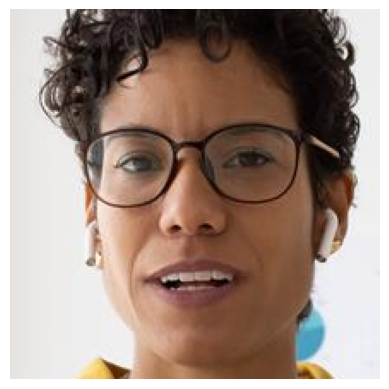

In [6]:
y0, y1, x0, x1 = face_boxes[0]
face_img = image_rgb[y0:y1, x0:x1, :]
plt.imshow(face_img)
plt.axis("off")
plt.show()

### Borrar a Imagem Inteira

Aplicamos um **desfoque Gaussiano** na imagem toda. O kernel `(51, 51)` precisa ser **ímpar**;
quanto maior, mais forte o desfoque. `sigma=0` faz o OpenCV calcular o desvio a partir do kernel.

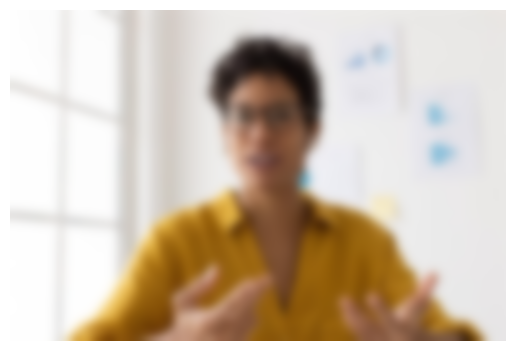

In [7]:
blured_image = cv2.GaussianBlur(image_rgb, (51, 51), 0)  # Borre a imagem inteira
plt.imshow(blured_image)
plt.axis("off")
plt.show()

### Substituir a Face Original na Imagem Borrada

Partimos da imagem **borrada** e, na região de cada rosto, colamos de volta os pixels **originais**
(nítidos). Fazendo isso para todas as caixas, funciona mesmo com mais de uma pessoa na foto.

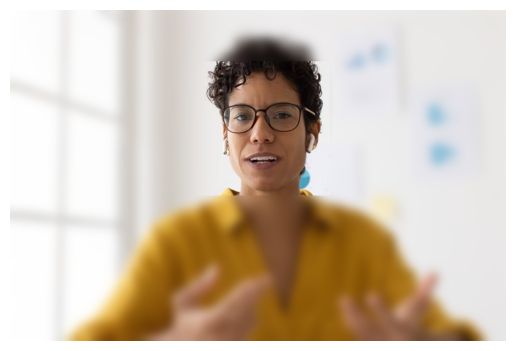

In [8]:
final_image = blured_image.copy()  # Começa da imagem borrada
for (y0, y1, x0, x1) in face_boxes:
    # A região da face recebe a imagem original (nítida)
    final_image[y0:y1, x0:x1, :] = image_rgb[y0:y1, x0:x1, :]

plt.imshow(final_image)
plt.axis("off")
plt.show()

> 📝 **Resultado:** rosto nítido sobre fundo desfocado, como nos apps de chamada de vídeo.
>
> **Limitações desta abordagem simples:** a máscara é um **retângulo** ao redor do rosto, então
> pescoço/ombros/cabelo podem ficar nítidos junto, e o recorte tem bordas duras. Soluções reais
> usam **segmentação de pessoa** (ex.: máscara do corpo inteiro) e suavizam a transição entre as
> regiões nítida e borrada.